In [197]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

## Loading the data

In [259]:
loaded_data_df = pd.read_excel('data/UK_Data.xlsx')

In [199]:
df=loaded_data_df.copy()

## Data Quality Assessment & Statistical Analysis

### Data Cleaning

In [ ]:
# how does data look like
print('\n Checking the num of records and attributes in the data:')
print(df.shape)
nnamed: 0	
df.head().T


 Checking the num of records and attributes in the data:
(333828, 10)


,0,1,2,3,4
Unnamed: 0,0,1,2,3,4
InvoiceNo,536365,536365,536365,536365,536365
StockCode,85123A,71053,84406B,84029G,84029E
Description,WHITE HANGING HEART T-LIGHT HOLDER,WHITE METAL LANTERN,CREAM CUPID HEARTS COAT HANGER,KNITTED UNION FLAG HOT WATER BOTTLE,RED WOOLLY HOTTIE WHITE HEART.
Quantity,6,6,8,6,6
InvoiceDate,2010-12-01 08:26:00,2010-12-01 08:26:00,2010-12-01 08:26:00,2010-12-01 08:26:00,2010-12-01 08:26:00
UnitPrice,2.55,3.39,2.75,3.39,3.39
CustomerID,17850,17850,17850,17850,17850
Country,United Kingdom,United Kingdom,United Kingdom,United Kingdom,United Kingdom
Amount,15.3,20.34,22.0,20.34,20.34


In [201]:
print('\nChecking types of data that each column stores: ')
df.info()


Checking types of data that each column stores: 
<class 'pandas.DataFrame'>
RangeIndex: 333828 entries, 0 to 333827
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Unnamed: 0   333828 non-null  int64         
 1   InvoiceNo    333828 non-null  int64         
 2   StockCode    333828 non-null  object        
 3   Description  333828 non-null  str           
 4   Quantity     333828 non-null  int64         
 5   InvoiceDate  333828 non-null  datetime64[us]
 6   UnitPrice    333828 non-null  float64       
 7   CustomerID   333828 non-null  int64         
 8   Country      333828 non-null  str           
 9   Amount       333828 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(4), object(1), str(2)
memory usage: 25.5+ MB


In [202]:
# renaming columns to make it easier to handle
df.columns = df.columns.str.strip().str.lower()
df.columns

Index(['unnamed: 0', 'invoiceno', 'stockcode', 'description', 'quantity',
       'invoicedate', 'unitprice', 'customerid', 'country', 'amount'],
      dtype='str')

In [203]:
# dropping useless column 'unnamed: 0'
df.drop(columns=['unnamed: 0'], inplace=True)

In [204]:
print('\nChecking if there are any null values: ')
print(df.isna().sum())


Checking if there are any null values: 
invoiceno      0
stockcode      0
description    0
quantity       0
invoicedate    0
unitprice      0
customerid     0
country        0
amount         0
dtype: int64


Since there are no missing values(null values), interpolation is not required in this case.

In [205]:
print('\nChecking if there are duplicates')
subset=['invoiceno','customerid','amount', 'quantity','invoicedate','unitprice', 'stockcode']
duplicated= df.duplicated(subset=subset, keep=False)
print(duplicated.sum())
df[duplicated].sort_values(['invoiceno', 'stockcode', 'quantity']).head(20)


Checking if there are duplicates
9801


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,amount
394,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908,United Kingdom,1.25
416,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908,United Kingdom,1.25
385,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908,United Kingdom,4.95
438,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908,United Kingdom,4.95
389,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908,United Kingdom,2.10
426,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908,United Kingdom,2.10
420,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908,United Kingdom,2.95
436,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908,United Kingdom,2.95
477,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920,United Kingdom,1.65
497,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920,United Kingdom,1.65


In [206]:
# since there are duplicates we remove them and keep only one
df.drop_duplicates(subset=subset, keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)

In [207]:
numerical_columns = ['quantity','unitprice', 'amount']
categorical_columns = ['stockcode', 'invoiceno', 'country', 'customerid']

print(df.columns)

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country', 'amount'],
      dtype='str')


In [208]:
print('\n Checking basic statistics for numerical columns:')
df[numerical_columns].describe()


 Checking basic statistics for numerical columns:


,quantity,unitprice,amount
count,328739.000000,328739.000000,328739.000000
mean,6.771274,2.954697,13.427268
std,6.576287,4.320993,16.093775
min,1.000000,0.000000,0.000000
25%,2.000000,1.250000,3.950000
50%,4.000000,1.950000,10.080000
75%,12.000000,3.750000,17.340000
max,27.000000,649.500000,838.800000


There are some unit price with 0 (indicated by the min(unitprice)). We need to look for more unconventional situations and clean data.

In [209]:
# checking why there is 0 in data
data_with_zero = df[df['unitprice'] ==  0.0]
print(f"There are {data_with_zero.shape[0]} records which has 0.0 amount and unit price")

There are 19 records which has 0.0 amount and unit price


Since there are few such records where unitprice = 0, we remove them. 

In [210]:
df = df[df["unitprice"] > 0]
print(df.shape)

(328720, 9)


In [211]:
# checking if there are some unconventional scenarios
returns = df[df['quantity'] < 0 ]
mis_calculation = (df['quantity'] * df['unitprice'] - df['amount']).abs().sum()

print(f"There are {returns.shape[0]} returns.")
print(f"The miscalculation figure: {mis_calculation}")

There are 0 returns.
The miscalculation figure: 1.422489348534839e-10


No returns and marginal miscalculation (due to rounding). Safe to ignore. Now, Looking into basic statistic again and seeing what data gives.

### Descriptive Statistics

In [212]:
df[numerical_columns].describe()

,quantity,unitprice,amount
count,328720.000000,328720.000000,328720.000000
mean,6.771200,2.954867,13.428044
std,6.576144,4.321059,16.093916
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,3.950000
50%,4.000000,1.950000,10.080000
75%,12.000000,3.750000,17.340000
max,27.000000,649.500000,838.800000


Here, in all of the cases data is right skewed. This means for each of the attribute there are more lower value items than higher value. The few of higher value items are increasing the mean. ie.
* There are more of low priced items (around 2-3 pounds) in store and few expensive ones (maximum is 649). The few luxury items is increasing the variability.
* Some bulk purchases are increasing the average, but generally people order small quantities.
* On average people spends about 13 in one purchase. However since there are few of the people who spends heftly, it is increasing the mean. Most people spends small amount.

In [213]:
print('\nChecking uniqueness for each categorical columns and amount sum:')
print(df[categorical_columns].nunique(dropna=False))
print(f"sum: {df['amount'].sum()}")
print(f"Time frame: {df['invoicedate'].min()} - {df['invoicedate'].max()}")


Checking uniqueness for each categorical columns and amount sum:
stockcode      3625
invoiceno     15443
country           1
customerid     3818
dtype: int64
sum: 4414066.714000001
Time frame: 2010-12-01 08:26:00 - 2011-12-09 12:49:00


Sales overview from 2010 December 1st to 2011 December 9th: \
Total Revenue: 4414066.71 \
Unique Products: 3625 \
Unique Customers: 3818 \
Total Transactions: 15443 

## Univariate, Bivariate and Multivariate Analysis

### Univariate Analysis

#### Numerical columns: Quantity, Amount, Unit Price

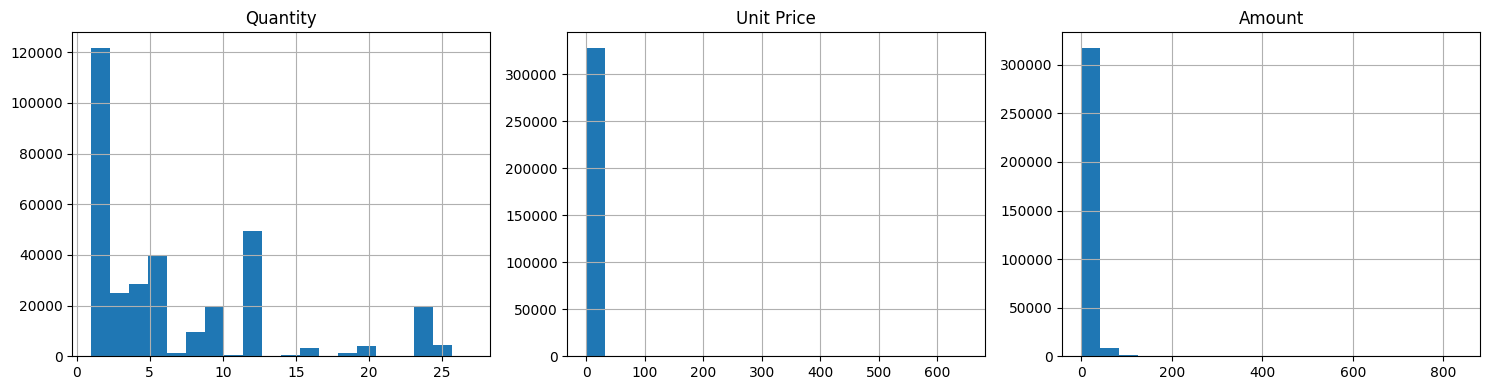

In [214]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4)) 

df['quantity'].hist(ax=axes[0], bins=20)
axes[0].set_title('Quantity')

df['unitprice'].hist(ax=axes[1], bins=20)
axes[1].set_title('Unit Price')

df['amount'].hist(ax=axes[2], bins=20)
axes[2].set_title('Amount')

plt.tight_layout()
plt.show()


From the histogram we can see that the values for Quantity, Unit Price and amount are clustured around the lower values. This shows right-skewness in the data. Quantity values are fairly distribited with a bit of skweness but the Unit Price and Amount have large no of datas clustered around lower values. From this we can infer that: 
* Customer tend to order in smaller quantities while there are few who ordered in bulk (>15units)
* There is variation in price range of the products where majority of products are of lesser price. There are few exception of high priced product no the store.
* The combined effect of choosing small quantities of low priced items is reflected in amount as well. 

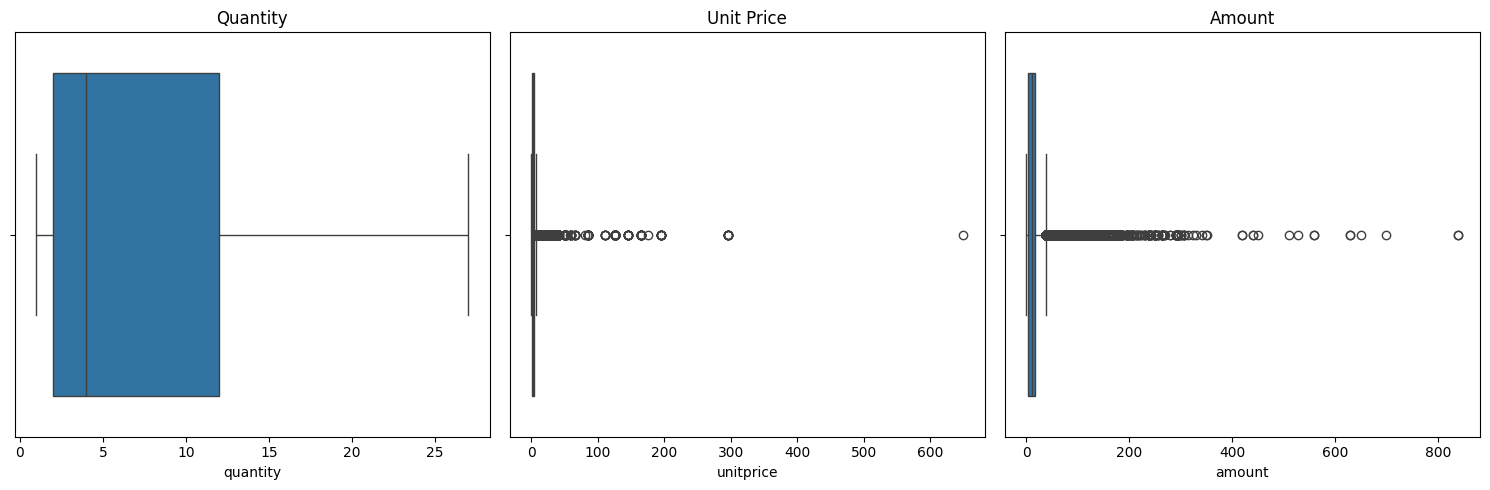

In [215]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(x=df['quantity'], ax=axes[0])
axes[0].set_title('Quantity')

sns.boxplot(x=df['unitprice'], ax=axes[1])
axes[1].set_title('Unit Price')

sns.boxplot(x=df['amount'], ax=axes[2])
axes[2].set_title('Amount')

plt.tight_layout()
plt.show()


Since the data is highly skewed and hard to visualize, we are using log scale transformation. This will expand the lower-value range and compresses the higher value range.

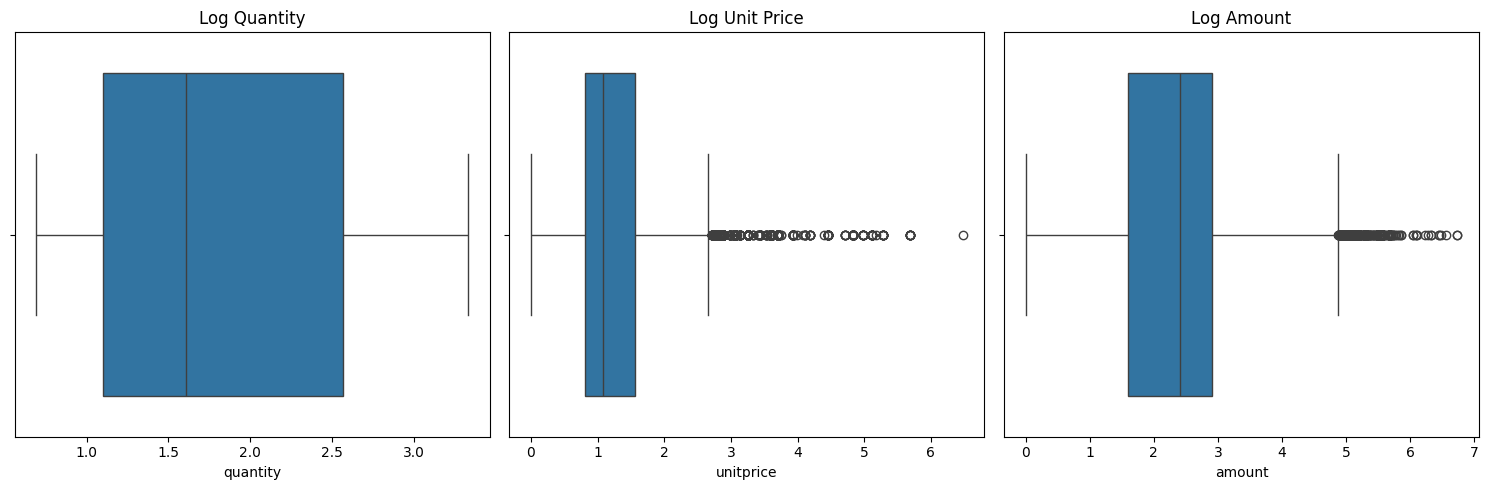

In [216]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(x=np.log1p(df['quantity']), ax=axes[0])
axes[0].set_title('Log Quantity')

sns.boxplot(x=np.log1p(df['unitprice']), ax=axes[1])
axes[1].set_title('Log Unit Price')

sns.boxplot(x=np.log1p(df['amount']), ax=axes[2])
axes[2].set_title('Log Amount')

plt.tight_layout()
plt.show()


In [217]:
from math import exp

def back_transform(log_value):
    return round((exp(log_value) - 1), 2)

data = [{
    'name': 'quantity',
    'median': 1.7,
    'q1': 1.2,
    'q3' : 2.6 
}, {
    'name': 'unit price',
    'median': 1.1,
    'q1': 0.8,
    'q3' : 1.6 
}, {
    'name': 'amount',
    'median': 2.4,
    'q1': 1.5,
    'q3' : 2.9 
}]

for variable in data:
    print(f'{variable['name']}') 
    print(f'Median: {back_transform(variable['median'])}') 
    print(f'IQR: {back_transform(variable['q1'])} - {back_transform(variable['q3'])}') 
    print('\n')

quantity
Median: 4.47
IQR: 2.32 - 12.46


unit price
Median: 2.0
IQR: 1.23 - 3.95


amount
Median: 10.02
IQR: 3.48 - 17.17




Looking at the box plot, we see that there are outliers present for unit price and the amount, indicating few of the items are expensive then normal, and few of the transaction are of either expensive product or of bulk order. 
* Most people order quantites 2-13 per item, with typical median of 4-5.
* Typical product ranges from £1 - £4 with most custered around £2. There are outliers which could be premium products or bulk price.
* Most invoice have around median of £6 per item item, generally between £3 - £14  

#### Categorical column: stockcode, customerid

In [218]:
# unique_combinations = df[['stockcode','description']].drop_duplicates()
# unique_combinations['stockcode'] = unique_combinations['stockcode'].astype(str)
# sorted_combinations = unique_combinations.sort_values('stockcode')
# print(sorted_combinations[sorted_combinations.duplicated(subset=['stockcode'])].head(50))


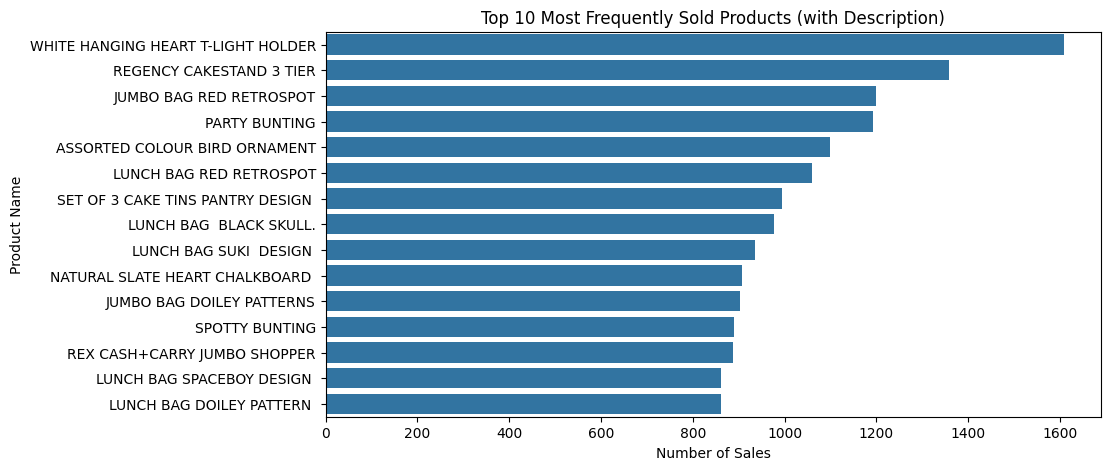

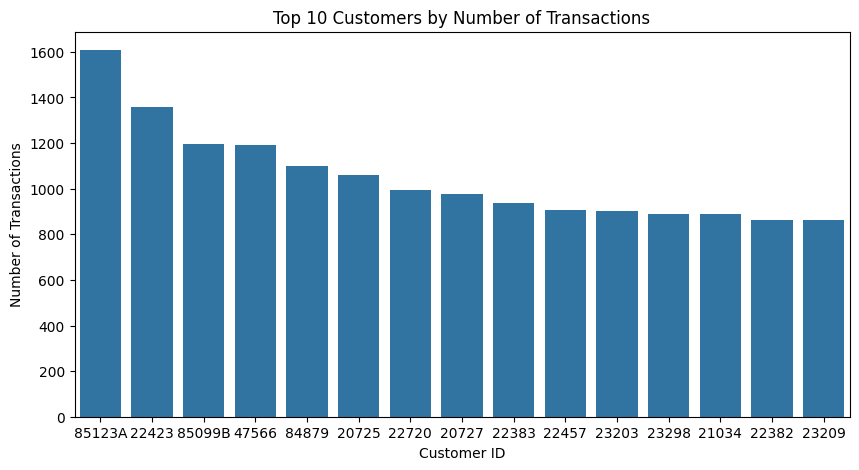

In [226]:
# Horizontal bar plot showing frequently sold products

product_counts = df['stockcode'].value_counts()
top_products = product_counts.head(15)
top_products_desc = df.groupby('stockcode')['description'].first().loc[top_products.index]

plt.figure(figsize=(10, 5))
sns.barplot(x=top_products.values, y=top_products_desc.values)
plt.title("Top 10 Most Frequently Sold Products (with Description)")
plt.xlabel("Number of Sales")
plt.ylabel("Product Name")
plt.show()


# Verical bar graph showing the top customer by transaction count
customer_counts = df['stockcode'].value_counts()
top_customers = customer_counts.head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_customers.index, y=top_customers.values)
plt.title("Top 10 Customers by Number of Transactions")
plt.xlabel("Customer ID")
plt.ylabel("Number of Transactions")
plt.show()

From above bar plot, we can identify most frequently sold product indicating demand for the product. Likewise, the customer with highest frequency of transaction showing the activeness of customer and potentially most spending customer. 

### Bivariate Analysis

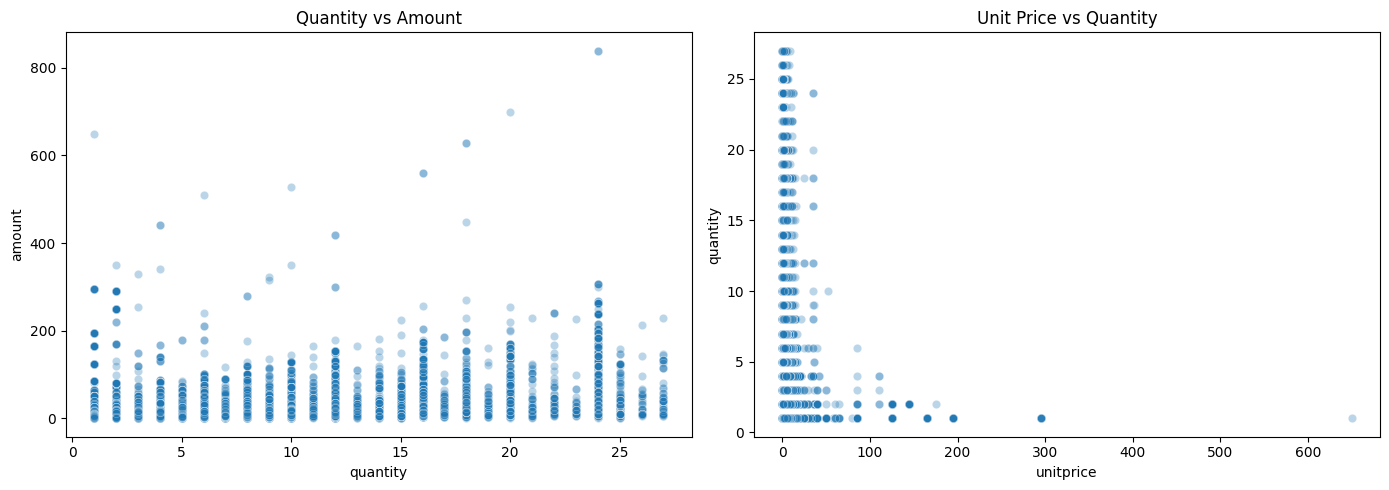

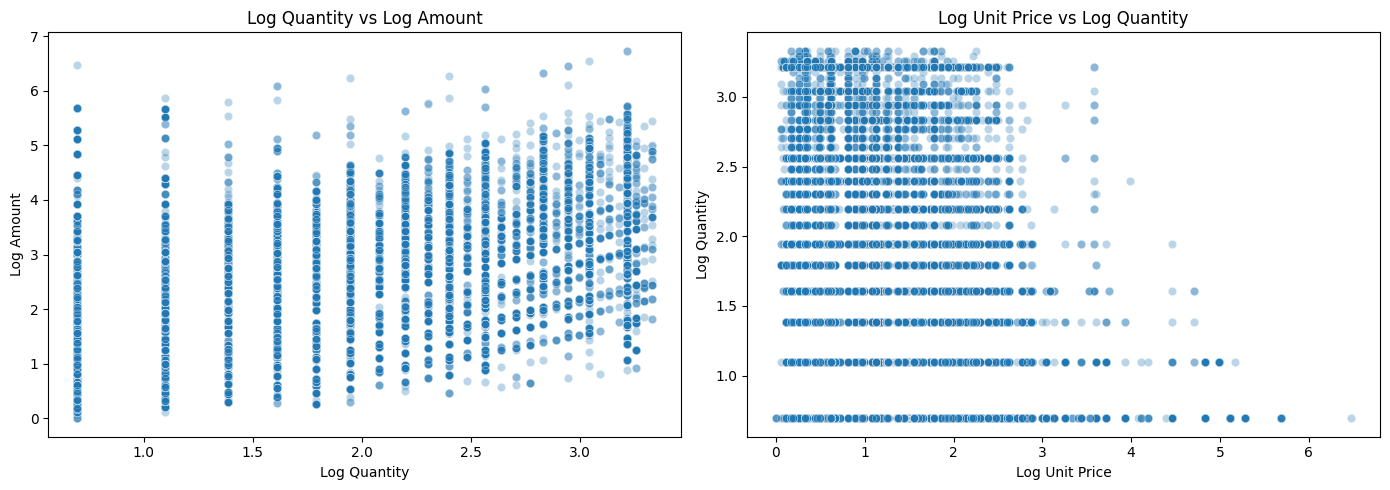

In [228]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# quantity vs amount
sns.scatterplot(
    x='quantity',
    y='amount',
    data=df,
    alpha=0.3,
    ax=axes[0]
)
axes[0].set_title('Quantity vs Amount')

# unit price vs amout
sns.scatterplot(
    x='unitprice',
    y='quantity',
    data=df,
    alpha=0.3,
    ax=axes[1]
)
axes[1].set_title('Unit Price vs Quantity')

plt.tight_layout()
plt.show()

# plotting data on log scale as data is highly skewed 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    x=np.log1p(df['quantity']),
    y=np.log1p(df['amount']),
    alpha=0.3,
    ax=axes[0]
)
axes[0].set_title('Log Quantity vs Log Amount')
axes[0].set_xlabel('Log Quantity')
axes[0].set_ylabel('Log Amount')


sns.scatterplot(
    x=np.log1p(df['unitprice']),
    y=np.log1p(df['quantity']),
    alpha=0.3,
    ax=axes[1]
)
axes[1].set_title('Log Unit Price vs Log Quantity')
axes[1].set_xlabel('Log Unit Price')
axes[1].set_ylabel('Log Quantity')

plt.tight_layout()
plt.show()


From the plot we can see that:
* On the log scale for quantity vs amount, the relationship is linear and positive. This makes sense intuitively as amount = quantity * unit price. 
* There is negative relation between the unit price and the quantity. This means expensive items are bought in fewer quantity.


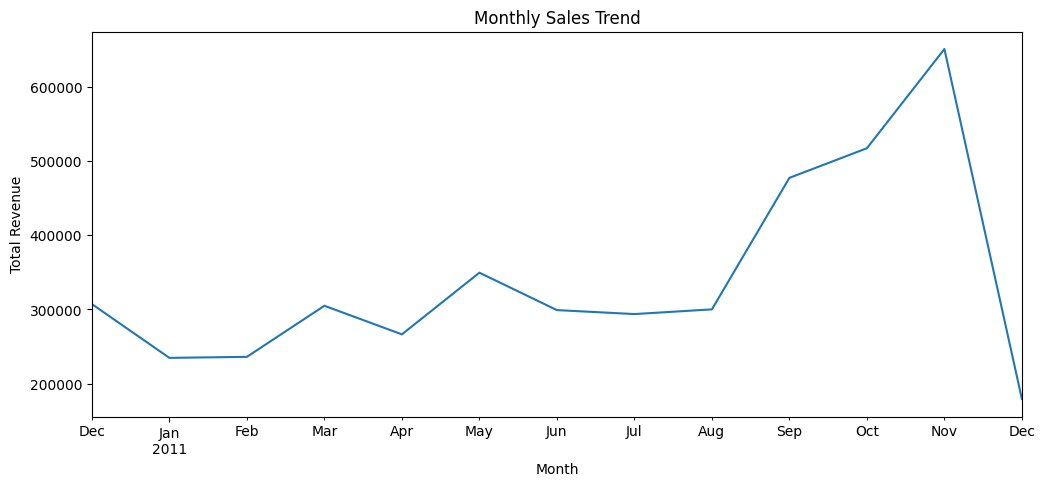

In [233]:
# time series data analysis

monthly_sales = df.groupby(df['invoicedate'].dt.to_period('M'))['amount'].sum()

monthly_sales.plot(figsize=(12,5))
plt.title("Monthly Sales Trend")
plt.ylabel("Total Revenue")
plt.xlabel("Month")
plt.show()


The line graph shows that there is fluctuation in the sales throughout the year.However on overall there is growth in sales from starting of year 2010 peaking near the end of the year. 

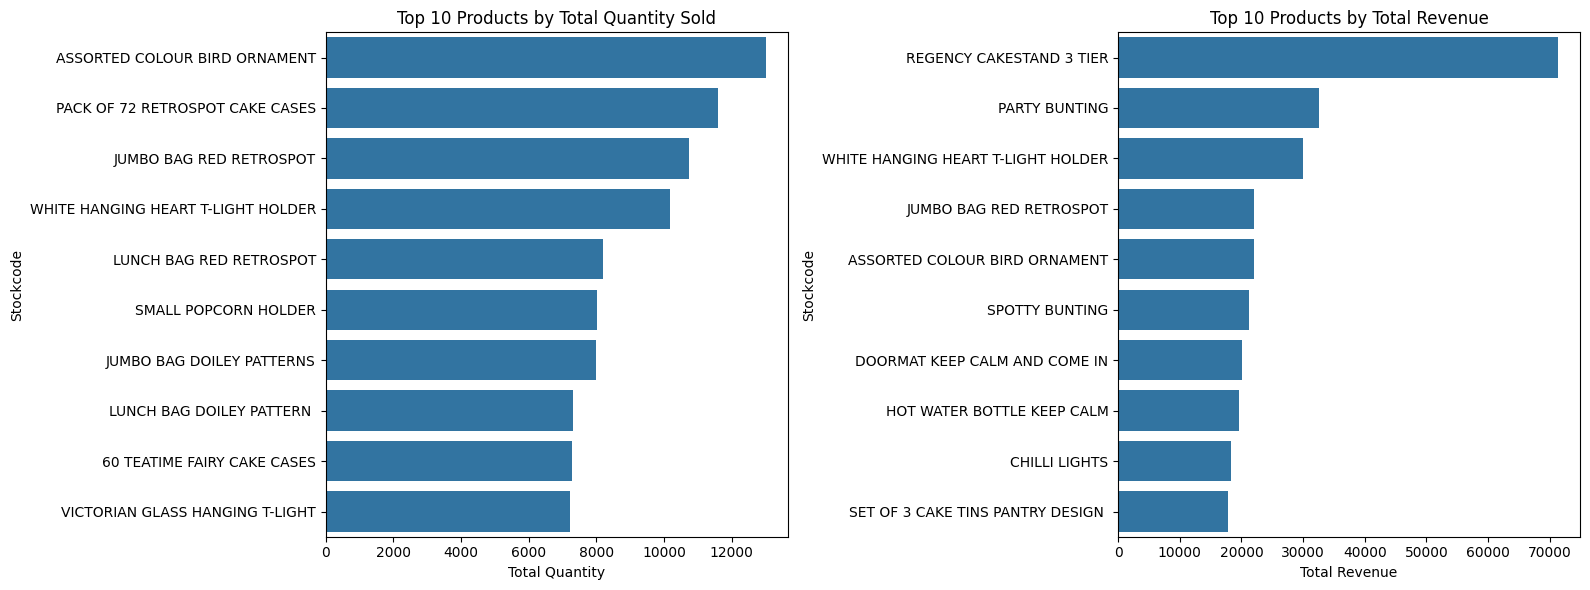

In [235]:
import matplotlib.pyplot as plt
import seaborn as sns

top_qty = df.groupby('stockcode')['quantity'].sum().sort_values(ascending=False).head(10)
top_rev = df.groupby('stockcode')['amount'].sum().sort_values(ascending=False).head(10)

top_qty_desc = df.groupby('stockcode')['description'].first().loc[top_qty.index]
top_rev_desc = df.groupby('stockcode')['description'].first().loc[top_rev.index]


fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Top  product by volume
sns.barplot(
    x=top_qty.values,
    y=top_qty_desc,
    ax=axes[0]
)
axes[0].set_title("Top 10 Products by Total Quantity Sold")
axes[0].set_xlabel("Total Quantity")
axes[0].set_ylabel("Stockcode")

# Top product by revenue
sns.barplot(
    x=top_rev.values,
    y=top_rev_desc,
    ax=axes[1]
)
axes[1].set_title("Top 10 Products by Total Revenue")
axes[1].set_xlabel("Total Revenue")
axes[1].set_ylabel("Stockcode")

plt.tight_layout()
plt.show()


The above comparision shows product with highest volume sold vs product with highest total revenue. There is one item common in both list is 'White hanging heart t-light holder' indicating the item is popular and generates high revenue as well; a star product. 

### Multivariate Analysis


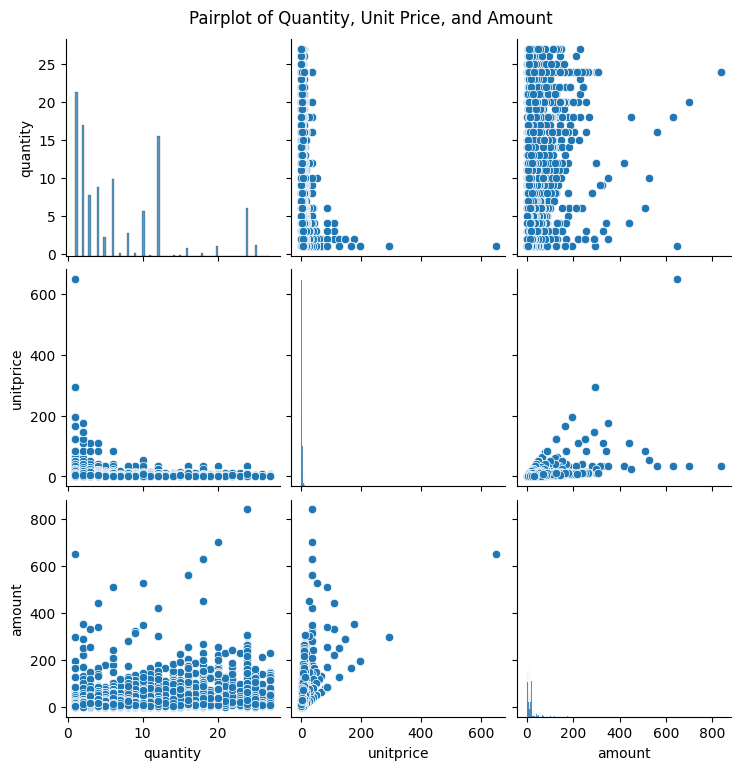

In [238]:


numeric_cols = ['quantity', 'unitprice', 'amount']

# # Optional: sample data if dataset is huge for faster plotting
# sample_df = df[numeric_cols].sample(5000, random_state=42)

# sns.pairplot(sample_df)
sns.pairplot(df[numeric_cols])
plt.suptitle("Pairplot of Quantity, Unit Price, and Amount", y=1.02)
plt.show()


As we already looked before on univariate analysis (histograms for quantity, unit price and amount) the data shows right skeweness. Similarly as discussed in bivariate analysis, quantity <-> amount shows positive linear relationship, unit price <-> quantity shows  ngative relation.

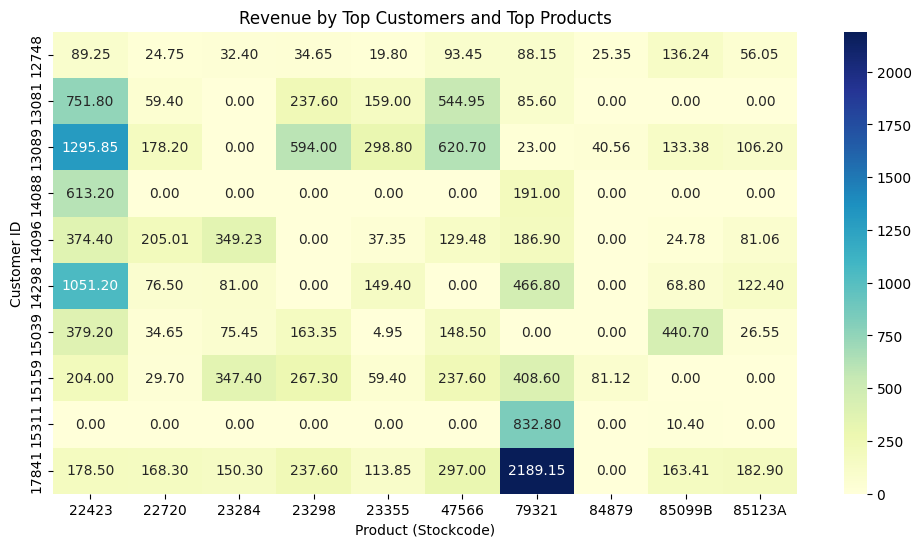

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: focus on top 10 customers and top 10 products to keep heatmap readable
top_customers = df.groupby('customerid')['amount'].sum().sort_values(ascending=False).head(10).index
top_products = df.groupby('stockcode')['amount'].sum().sort_values(ascending=False).head(10).index

pivot = df[df['customerid'].isin(top_customers) & df['stockcode'].isin(top_products)] \
        .pivot_table(index='customerid', columns='stockcode', values='amount', aggfunc='sum', fill_value=0)


plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title("Revenue by Top Customers and Top Products")
plt.xlabel("Product (Stockcode)")
plt.ylabel("Customer ID")
plt.show()




We see that first and 7th product is popular with the top customers. Few of them are not popular with the popular customers.
Few top Customers have bought two or less top revenue generating product.

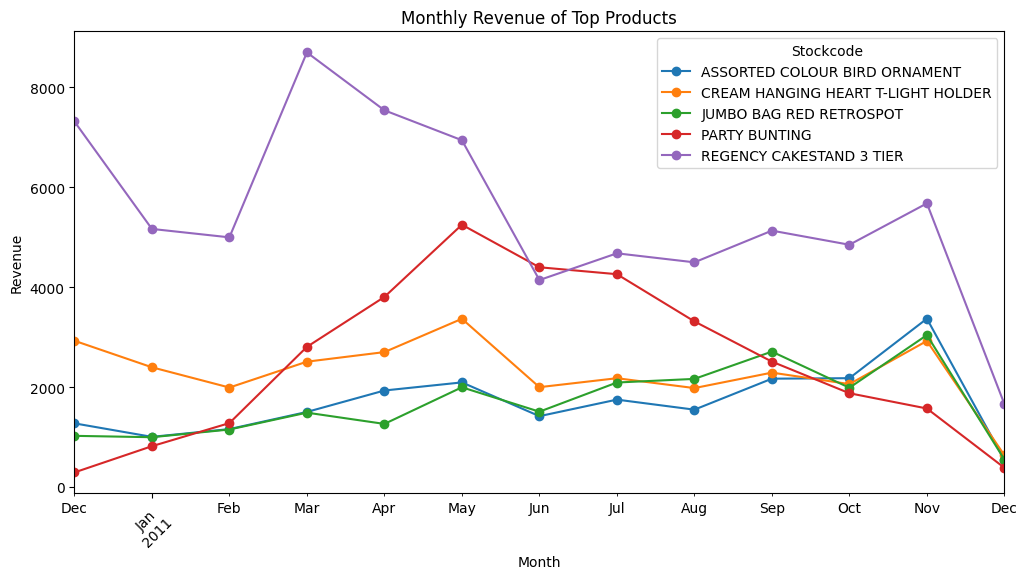

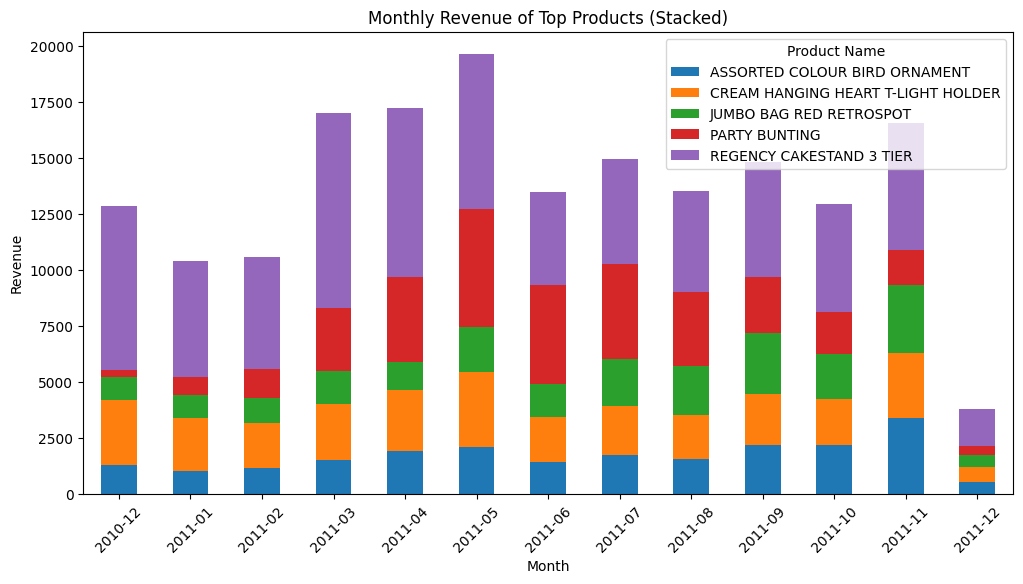

In [ ]:
product_map = df.set_index('stockcode')['description'].to_dict()

top_products = df.groupby('stockcode')['amount'].sum().sort_values(ascending=False).head(5).index

top_df = df[df['stockcode'].isin(top_products)].copy()

top_df['product_name'] = top_df['stockcode'].map(product_map)

top_df['month'] = top_df['invoicedate'].dt.to_period('M')

monthly_revenue = top_df.groupby(['month', 'product_name'])['amount'].sum().unstack(fill_value=0)


monthly_revenue.plot(figsize=(12,6), marker='o')
plt.title("Monthly Revenue of Top Products")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(title='Stockcode')
plt.show()


monthly_revenue.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Monthly Revenue of Top Products (Stacked)")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(title='Product Name')
plt.show()

In [250]:
customer_metrics = df.groupby('customerid').agg({
    'amount': 'sum',              # Total revenue per customer
    'invoiceno': 'nunique',       # Number of transactions
    'stockcode': 'nunique'        # Number of unique products purchased
}).rename(columns={
    'amount': 'total_revenue',
    'invoiceno': 'num_transactions',
    'stockcode': 'num_products'
}).reset_index()

customer_metrics.head()

,customerid,total_revenue,num_transactions,num_products
0,12747,3073.41,11,42
1,12748,24252.75,200,1733
2,12749,4032.98,5,158
3,12820,923.62,4,54
4,12821,92.72,1,6


In [251]:
revenue_quartiles = customer_metrics['total_revenue'].quantile([0.25, 0.5, 0.75])
freq_quartiles = customer_metrics['num_transactions'].quantile([0.25, 0.5, 0.75])

# Example: create High/Medium/Low for revenue
def categorize(value, quantiles):
    if value <= quantiles[0.25]: return 'Low'
    elif value <= quantiles[0.75]: return 'Medium'
    else: return 'High'

customer_metrics['revenue_segment'] = customer_metrics['total_revenue'].apply(lambda x: categorize(x, revenue_quartiles))
customer_metrics['frequency_segment'] = customer_metrics['num_transactions'].apply(lambda x: categorize(x, freq_quartiles))

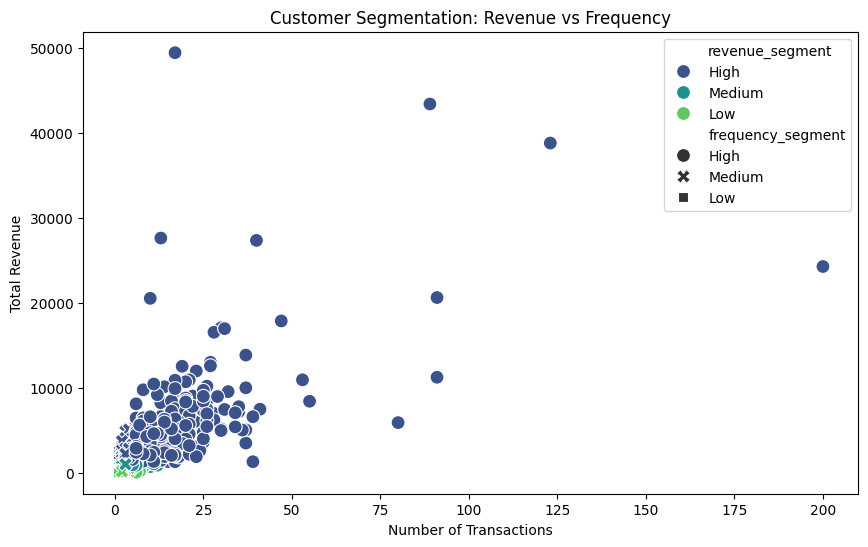

In [252]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='num_transactions', 
    y='total_revenue', 
    hue='revenue_segment', 
    style='frequency_segment',
    data=customer_metrics,
    s=100,
    palette='viridis'
)
plt.title("Customer Segmentation: Revenue vs Frequency")
plt.xlabel("Number of Transactions")
plt.ylabel("Total Revenue")
plt.show()

Here there are few customers (top-right) that frequently buys and contribute high towards the revenue. These customers can be regarded as important as they buy frequently and spend a lot 

When we add size as num of products in the plot we can see customers with diverse product purchases.Those customers who have bought large variety of products (1000+) seems to have higher num of transaction. These kind of customers could fall under outliers but are very important as they contribute a lot towards the revenue.

<Axes: xlabel='num_transactions', ylabel='total_revenue'>

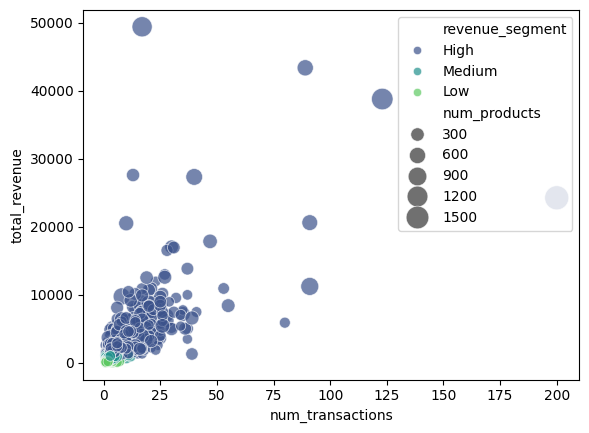

In [253]:
sns.scatterplot(
    x='num_transactions', 
    y='total_revenue', 
    size='num_products',
    hue='revenue_segment', 
    data=customer_metrics,
    sizes=(50, 300),
    palette='viridis',
    alpha=0.7
)


In [258]:
# customer_revenue = df.groupby('customerid')['amount'].sum().sort_values(ascending=False)
# top_customers = customer_revenue.head(10)

# plt.figure(figsize=(10,6))
# sns.barplot(x=top_customers.values, y=top_customers.index, palette='viridis')
# plt.title("Top 10 Customers by Revenue")
# plt.xlabel("Total Revenue")
# plt.ylabel("Customer ID")
# plt.show()

# top_customers.plot(kind='pie', y='amount', autopct='%1.1f%%', figsize=(7,7))
# plt.ylabel('')
# plt.title("Revenue Share of Top 10 Customers")
# plt.show()
